In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR,SVC
import pickle
import warnings
warnings.filterwarnings("ignore")

Data Loading

In [147]:
df = pd.read_csv("Exam_Score_Prediction.csv")

Data Exploration

In [148]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [149]:
df.tail()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
19995,19997,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,19998,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19999,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,20000,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0
19999,20001,20,male,b.sc,7.50,47.9,yes,7.5,poor,coaching,medium,moderate,71.0


In [150]:
print("Row", df.shape[0])
print("column", df.shape[1])


Row 20000
column 13


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [152]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


In [153]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [154]:
df.rename(columns={ "student_id":"id", "class_attendance": "attendance", "exam_score":"Score"}, inplace=True)

In [132]:
df.sample()

,id,age,gender,course,study_hours,attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,Score
5513,5514,23,male,b.com,7.51,62.8,yes,6.5,poor,self-study,high,moderate,65.3


In [155]:
df.nunique()

id                 20000
age                    8
gender                 3
course                 7
study_hours          784
attendance           589
internet_access        2
sleep_hours           59
sleep_quality          3
study_method           5
facility_rating        3
exam_difficulty        3
Score                805
dtype: int64

In [156]:
df["study_hours"].value_counts()

study_hours
7.91    225
0.08    210
5.61     42
0.90     41
2.81     41
       ... 
1.93     14
0.37     13
1.14     13
1.84     12
5.16     11
Name: count, Length: 784, dtype: int64

Data preprocessing

In [157]:
df.isnull().sum()

id                 0
age                0
gender             0
course             0
study_hours        0
attendance         0
internet_access    0
sleep_hours        0
sleep_quality      0
study_method       0
facility_rating    0
exam_difficulty    0
Score              0
dtype: int64

In [158]:
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')


In [159]:
df.corr()

,id,age,gender,course,study_hours,attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,Score
id,1.000000,-0.002574,-0.001506,-0.013417,0.002116,0.001128,0.001485,-0.000560,-0.007283,-0.002400,-0.007286,-0.016373,0.003269
age,-0.002574,1.000000,-0.001143,0.006056,0.002955,0.008449,-0.005839,-0.000385,-0.002935,-0.006130,-0.006287,0.017837,0.006522
gender,-0.001506,-0.001143,1.000000,0.014845,0.001540,-0.002129,-0.004433,-0.005258,0.000454,-0.004945,0.001113,-0.000313,-0.000428
course,-0.013417,0.006056,0.014845,1.000000,-0.004294,-0.004932,-0.006307,0.002474,0.005533,-0.008628,0.003464,0.003149,-0.000448
study_hours,0.002116,0.002955,0.001540,-0.004294,1.000000,-0.001645,-0.012706,-0.004533,0.005389,-0.001920,0.009842,0.005630,0.717788
attendance,0.001128,0.008449,-0.002129,-0.004932,-0.001645,1.000000,0.006729,0.007187,0.003473,-0.002734,-0.005879,-0.005156,0.308850
internet_access,0.001485,-0.005839,-0.004433,-0.006307,-0.012706,0.006729,1.000000,-0.010066,-0.004282,0.012887,0.004754,-0.004186,-0.007826
sleep_hours,-0.000560,-0.000385,-0.005258,0.002474,-0.004533,0.007187,-0.010066,1.000000,-0.010000,0.001744,0.003587,0.000007,0.133222
sleep_quality,-0.007283,-0.002935,0.000454,0.005533,0.005389,0.003473,-0.004282,-0.010000,1.000000,0.008127,-0.003511,-0.004169,-0.099725
study_method,-0.002400,-0.006130,-0.004945,-0.008628,-0.001920,-0.002734,0.012887,0.001744,0.008127,1.000000,-0.001155,0.003112,-0.154610


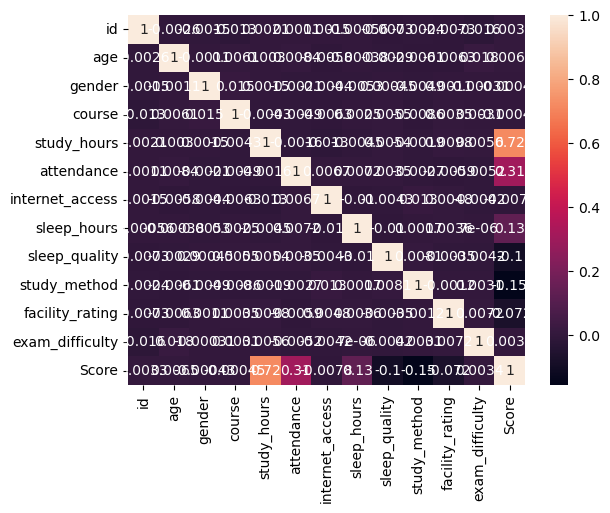

In [160]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
df.fillna(df.mean(), inplace=True)
df['study_hours'].fillna(df['study_hours'].mean(), inplace=True)


cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

df.dropna(inplace=True)



In [164]:
df = pd.get_dummies(df, columns=['course', 'sleep_quality', 'study_method', 
                                 'facility_rating', 'exam_difficulty'], drop_first=True)


In [ ]:
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

0


In [166]:
X = df.drop('Score', axis=1)
y = df['Score']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [182]:
df.to_csv('processed_data.csv', index=False, header=True)

Data splitting

In [ ]:
X = df.drop('Score', axis=1)  # features
y = df['Score']               # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [177]:

model = SVR(kernel='rbf')  
model.fit(X_train, y_train)  # Train the model


SVR()

Displaying Accuracy

In [176]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = r2 * 100
print(f"Model Accuracy: {accuracy:.2f}%")

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Model Accuracy: 0.01%
Mean Squared Error: 357.65041276865685
R2 Score: 0.0001302919787018464


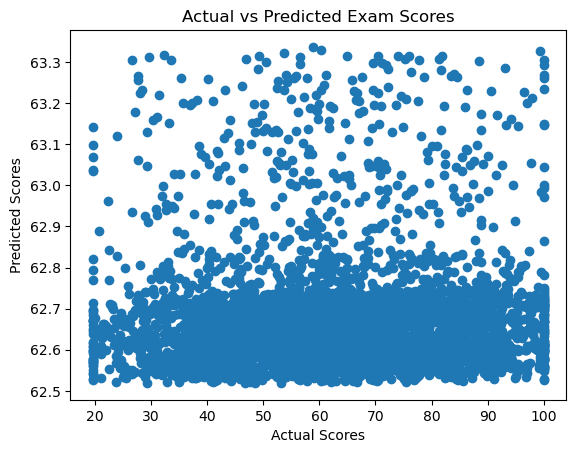

In [173]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Exam Scores")
plt.show()

In [174]:
print(f"R2 Score: {r2:.2f}")
print(f"Mean Squared Error: {mse:.2f}")


R2 Score: 0.00
Mean Squared Error: 357.65


In [181]:
model = SVR(kernel='rbf')
model.fit(X_train, y_train)

pickle.dump(model, open('model_svc.pkl', 'wb'))  
loaded_model = pickle.load(open('model_svc.pkl', 'rb'))
y_pred = loaded_model.predict(X_test)
